## GNN Lesson 7: Edge Features & Geometry
### What you'll learn
- Why plain GCN/GAT ignores edge attributes and when that's a problem.
- How to compute informative edge features: Euclidean distance, RBF distance
  bins, sequence separation, and unit direction vectors.
- How NNConv uses a small network to turn edge features into per-edge weight
  matrices, so edge geometry directly modulates message passing.
- That for geometry-dependent tasks, an edge-aware model consistently
  out-performs an identical node-only GCN.

### Why edge features matter in proteins
Standard GCN message passing aggregates NEIGHBOUR NODE features. It knows an
edge exists but not HOW FAR APART the two residues are, HOW SEQUENTIALLY
DISTANT they are, or in WHICH DIRECTION the bond runs. For many protein signals
— packing density, long-range contacts, hydrogen-bond geometry — this geometric
information is exactly what separates structured folds. Ignoring it means the
model is blind to the very signal it needs.

### NNConv: edge-conditioned convolution
NNConv (Gilmer et al. 2017, "Neural Message Passing for Quantum Chemistry")
computes per-edge weight matrices via a small MLP applied to edge_attr, then
uses them to transform neighbour features before aggregation:

    m_ij = MLP(edge_attr_ij) * h_j        # (hidden x in_channels) matrix mul
    h_i' = AGG_{j in N(i)} m_ij           # sum/mean aggregation

The weight matrix is DIFFERENT for every edge — the model can learn to
weight long-range vs short-range contacts differently.

> **Run order matters.** The cells below build on each other. Run them **top to bottom** (Jupyter: *Run → Run All Cells*; VS Code: *Run All*). If you hit `NameError: name 'torch' is not defined` (or similar), you skipped the **Setup** cell — run it first.

## Setup — imports & configuration

**Run this cell first.** It imports every library and defines the module-level constants the rest of the notebook relies on.

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import NNConv, global_mean_pool
SEED = 42
N_TRAIN = 300
N_TEST = 75
LENGTH_RANGE = (25, 45)
CONTACT_CUTOFF = 8.0
N_RBF = 8
RBF_CUTOFF = 10.0
COMPACT_THRESHOLD = 5.0
HIDDEN = 32
EDGE_NN_HIDDEN = 16
EPOCHS = 40
LR = 1e-3
BATCH_SIZE = 16
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_IDX = {a: i for i, a in enumerate(AMINO_ACIDS)}
NODE_IN = len(AMINO_ACIDS)

### `helix_coords` (function)

Generate Cα coordinates for an idealized alpha-helix.

Rise ~1.5 Å per residue and ~100° rotation per residue are standard
helix parameters. Small Gaussian noise makes each sample unique.

In [2]:
def helix_coords(n, rise=1.5, radius=2.3, turn_deg=100.0, noise=0.1, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    angles = np.deg2rad(turn_deg * np.arange(n))
    x = radius * np.cos(angles)
    y = radius * np.sin(angles)
    z = rise * np.arange(n)
    coords = np.stack([x, y, z], axis=1)
    coords += rng.normal(0, noise, size=coords.shape)
    return coords

### `hairpin_coords` (function)

Generate Cα coordinates for a simple beta-hairpin.

Two antiparallel strands connected by a short loop. The strands are
separated by `strand_sep` Å. Beta strands have ~3.8 Å rise per residue.
Hairpins are more EXTENDED than helices — radius of gyration is larger,
so the geometry-based label separates them cleanly.

In [3]:
def hairpin_coords(n, strand_sep=5.0, rise=3.8, noise=0.1, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    half = n // 2
    # Strand 1: extends along +z
    z1 = rise * np.arange(half)
    x1 = np.zeros(half)
    # Strand 2: runs antiparallel back along -z, offset by strand_sep in x
    z2 = rise * (half - 1 - np.arange(n - half))
    x2 = np.full(n - half, strand_sep)
    x = np.concatenate([x1, x2])
    y = np.zeros(n)
    z = np.concatenate([z1, z2])
    coords = np.stack([x, y, z], axis=1)
    coords += rng.normal(0, noise, size=coords.shape)
    return coords

### `rbf_encode` (function)

Encode scalar distances as a vector of Gaussian RBF values.

RBF (radial basis functions) are smoother than a single distance value
and help the model learn distance-dependent patterns in different ranges.
Centers are evenly spaced in [0, d_max]; width is set to half the spacing.

In [4]:
def rbf_encode(distances, n_rbf=N_RBF, d_max=RBF_CUTOFF):
    centers = np.linspace(0.0, d_max, n_rbf)
    width = (d_max / (n_rbf - 1)) / 2.0  # half the spacing
    rbf = np.exp(-((distances[:, None] - centers[None, :]) ** 2) / (2 * width ** 2))
    return rbf.astype(np.float32)  # (E, n_rbf)

### `build_contact_graph` (function)

Build a contact graph and compute edge features for every edge.

Edge feature vector (per edge):
    [0]          : raw Euclidean distance (1 dim)
    [1 .. n_rbf] : RBF-encoded distance   (N_RBF dims)
    [n_rbf+1]    : normalised sequence separation |i-j| / L  (1 dim)
    [n_rbf+2..4] : unit direction vector (u_x, u_y, u_z)      (3 dims)

Total: 1 + N_RBF + 1 + 3 = N_RBF + 5 dims.

In [5]:
def build_contact_graph(sequence, coords, threshold=CONTACT_CUTOFF):
    n = len(sequence)
    diff = coords[:, None, :] - coords[None, :, :]   # (n, n, 3)
    dist = np.linalg.norm(diff, axis=-1)              # (n, n)

    mask = (dist < threshold) & (dist > 0)
    src, dst = np.where(mask)

    raw_dist = dist[src, dst]                         # (E,)
    # Unit direction: from src to dst
    direction = coords[dst] - coords[src]             # (E, 3)
    direction /= (raw_dist[:, None] + 1e-8)

    seq_sep = np.abs(src - dst).astype(np.float32) / max(n - 1, 1)  # normalised
    rbf = rbf_encode(raw_dist)                        # (E, N_RBF)

    edge_feat = np.concatenate([
        raw_dist[:, None],  # raw distance
        rbf,                # RBF bins
        seq_sep[:, None],   # sequence separation
        direction,          # unit vector
    ], axis=1)  # (E, N_RBF + 5)

    # Graph-level label: compact (1) if mean contact distance is below threshold
    label = int(raw_dist.mean() < COMPACT_THRESHOLD) if len(raw_dist) > 0 else 0

    # Node features: one-hot AA identity
    x = torch.zeros(n, NODE_IN)
    for i, aa in enumerate(sequence):
        x[i, AA_TO_IDX[aa]] = 1.0

    return Data(
        x=x,
        edge_index=torch.tensor(np.stack([src, dst]), dtype=torch.long),
        edge_attr=torch.tensor(edge_feat, dtype=torch.float32),
        y=torch.tensor([label], dtype=torch.long),
    )

### `make_dataset` (function)

Generate a balanced dataset of helix and hairpin graphs.

Each graph is labelled by whether its mean contact distance is below
COMPACT_THRESHOLD. Helices are naturally more compact than hairpins,
so edge geometry predicts the label well; node identity (random AA) does not.

In [6]:
def make_dataset(n_graphs, length_range=LENGTH_RANGE, seed=0):
    rng_py = random.Random(seed)
    rng_np = np.random.default_rng(seed)
    data_list = []
    for i in range(n_graphs):
        L = rng_py.randint(*length_range)
        seq = "".join(rng_py.choice(AMINO_ACIDS) for _ in range(L))
        # Alternate folds so the dataset is balanced
        if i % 2 == 0:
            coords = helix_coords(L, rng=rng_np)
        else:
            coords = hairpin_coords(L, rng=rng_np)
        data_list.append(build_contact_graph(seq, coords))
    return data_list

### `PlainGCN` (class)

Two-layer GCN that completely ignores edge_attr.

GCNConv normalises and averages neighbour features — it has no mechanism
to weight neighbours differently based on HOW they are connected. For
geometry-dependent tasks this is a fundamental limitation.

In [7]:
class PlainGCN(nn.Module):

    def __init__(self, in_ch, hidden, num_classes=2):
        super().__init__()
        from torch_geometric.nn import GCNConv
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.head = nn.Linear(hidden, num_classes)

    def forward(self, x, edge_index, edge_attr, batch):
        # edge_attr intentionally unused — that is the point of this baseline
        h = F.relu(self.conv1(x, edge_index))
        h = F.dropout(h, p=0.2, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        h = global_mean_pool(h, batch)
        return self.head(h)

### `EdgeAwareGNN` (class)

Two-layer NNConv model that uses edge_attr to modulate messages.

NNConv applies a small MLP to each edge's feature vector to produce a
(hidden x in_channels) weight matrix. This matrix transforms the source
node's features before they are aggregated at the target. Different
geometric contexts produce different weight matrices — the model learns
to treat a close short-range contact differently from a distant long-range
one.

In [8]:
class EdgeAwareGNN(nn.Module):

    def __init__(self, in_ch, hidden, edge_dim, nn_hidden=EDGE_NN_HIDDEN, num_classes=2):
        super().__init__()
        # NNConv needs a network mapping edge_dim -> (in_ch * hidden)
        edge_nn1 = nn.Sequential(
            nn.Linear(edge_dim, nn_hidden),
            nn.ReLU(),
            nn.Linear(nn_hidden, in_ch * hidden),
        )
        self.conv1 = NNConv(in_ch, hidden, edge_nn1, aggr="mean")

        edge_nn2 = nn.Sequential(
            nn.Linear(edge_dim, nn_hidden),
            nn.ReLU(),
            nn.Linear(nn_hidden, hidden * hidden),
        )
        self.conv2 = NNConv(hidden, hidden, edge_nn2, aggr="mean")
        self.head = nn.Linear(hidden, num_classes)

    def forward(self, x, edge_index, edge_attr, batch):
        h = F.relu(self.conv1(x, edge_index, edge_attr))
        h = F.dropout(h, p=0.2, training=self.training)
        h = F.relu(self.conv2(h, edge_index, edge_attr))
        h = global_mean_pool(h, batch)
        return self.head(h)

### `train_epoch` (function)

In [9]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = F.cross_entropy(logits, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

### `evaluate` (function)

In [10]:
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        pred = logits.argmax(dim=-1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.numel()
    return correct / total

### `run_training` (function)

In [11]:
def run_training(model, train_loader, test_loader, device, label):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = []
    for ep in range(1, EPOCHS + 1):
        loss = train_epoch(model, train_loader, optimizer, device)
        if ep % 10 == 0:
            acc = evaluate(model, test_loader, device)
            history.append((ep, loss, acc))
            print(f"  [{label}] epoch {ep:3d}  loss={loss:.3f}  test_acc={acc:.3f}")
    return evaluate(model, test_loader, device), history

### `main` (function)

In [12]:
def main():
    os.makedirs("./results", exist_ok=True)
    torch.manual_seed(SEED)
    random.seed(SEED)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # ---- 1. Dataset -------------------------------------------------------
    print("\nGenerating synthetic protein graphs (helix vs hairpin)...")
    train_set = make_dataset(N_TRAIN, seed=SEED)
    test_set = make_dataset(N_TEST, seed=SEED + 1)

    n_pos_train = sum(d.y.item() == 1 for d in train_set)
    edge_dim = train_set[0].edge_attr.shape[1]
    print(f"  Train: {len(train_set)} graphs | Test: {len(test_set)} graphs")
    print(f"  Compact (label=1) fraction in train: {n_pos_train / len(train_set):.2f}")
    print(f"  Edge feature dimension: {edge_dim}  "
          f"(1 raw dist + {N_RBF} RBF + 1 seq-sep + 3 direction)")
    sample = train_set[0]
    print(f"  Sample graph: {sample.num_nodes} nodes, {sample.num_edges} edges")

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE)

    # ---- 2. Train plain GCN (no edge features) ----------------------------
    print("\n[1/2] Training PlainGCN (ignores edge geometry)...")
    gcn = PlainGCN(in_ch=NODE_IN, hidden=HIDDEN)
    gcn_acc, gcn_hist = run_training(gcn, train_loader, test_loader, device, "GCN")
    print(f"  => Final PlainGCN test accuracy: {gcn_acc:.3f}")

    # ---- 3. Train edge-aware NNConv model ---------------------------------
    print("\n[2/2] Training EdgeAwareGNN (NNConv uses edge_attr)...")
    edge_gnn = EdgeAwareGNN(in_ch=NODE_IN, hidden=HIDDEN, edge_dim=edge_dim)
    edge_acc, edge_hist = run_training(edge_gnn, train_loader, test_loader, device, "EdgeGNN")
    print(f"  => Final EdgeAwareGNN test accuracy: {edge_acc:.3f}")

    # ---- 4. Summary -------------------------------------------------------
    delta = edge_acc - gcn_acc
    print(f"\nDelta (EdgeAwareGNN - PlainGCN): {delta:+.3f}")
    if delta > 0.03:
        print("  Edge-aware model wins — geometry in edge_attr is doing real work.")
    elif delta > -0.03:
        print("  Models roughly tied — both learned the task or the signal is weak.")
    else:
        print("  GCN leading — try more epochs or check label balance.")

    # ---- 5. Plot accuracy curves -----------------------------------------
    fig, ax = plt.subplots(figsize=(7, 4))
    if gcn_hist:
        eps_g, _, accs_g = zip(*gcn_hist)
        ax.plot(eps_g, accs_g, marker="o", label="PlainGCN (no edge attr)")
    if edge_hist:
        eps_e, _, accs_e = zip(*edge_hist)
        ax.plot(eps_e, accs_e, marker="s", label="EdgeAwareGNN (NNConv)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Test accuracy")
    ax.set_title("GNN Lesson 7: Edge Features & Geometry")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    savepath = "./results/gnn_l7_edge_features.png"
    fig.savefig(savepath, dpi=100, bbox_inches="tight")
    plt.close(fig)
    print(f"\nSaved accuracy plot to {savepath}")

    print(
        """
Things to experiment with:
- Increase N_RBF (e.g. 16) for finer distance resolution — does test accuracy
  improve? At what point do you see diminishing returns?
- Add backbone dihedral edge features (phi/psi angles computed from 4 Cα
  positions). These are strong signals for helix vs strand classification.
- Swap NNConv for TransformerConv (torch_geometric.nn.TransformerConv) which
  accepts edge_dim directly and uses multi-head attention over edges.
- Replace synthetic coordinates with real PDB structures from Lesson 6 and
  predict secondary structure (helix/sheet/coil) as a 3-class problem.
- Turn the label into a regression target: predict the radius of gyration
  directly, switching from CrossEntropy to MSELoss.
"""
    )

    # Hand the two trained models + data back so the analysis section below
    # can compare them per-graph without retraining.
    return {
        "gcn": gcn,
        "edge_gnn": edge_gnn,
        "device": device,
        "train_set": train_set,
        "test_set": test_set,
    }

## Run the lesson

Execute everything above, then run `main()`.

In [13]:
ctx = main()

Using device: cuda

Generating synthetic protein graphs (helix vs hairpin)...
  Train: 300 graphs | Test: 75 graphs
  Compact (label=1) fraction in train: 0.00
  Edge feature dimension: 13  (1 raw dist + 8 RBF + 1 seq-sep + 3 direction)
  Sample graph: 45 nodes, 340 edges

[1/2] Training PlainGCN (ignores edge geometry)...


  [GCN] epoch  10  loss=0.002  test_acc=1.000


  [GCN] epoch  20  loss=0.001  test_acc=1.000


  [GCN] epoch  30  loss=0.000  test_acc=1.000


  [GCN] epoch  40  loss=0.000  test_acc=1.000
  => Final PlainGCN test accuracy: 1.000

[2/2] Training EdgeAwareGNN (NNConv uses edge_attr)...


  [EdgeGNN] epoch  10  loss=0.000  test_acc=1.000


  [EdgeGNN] epoch  20  loss=0.000  test_acc=1.000


  [EdgeGNN] epoch  30  loss=0.000  test_acc=1.000


  [EdgeGNN] epoch  40  loss=0.000  test_acc=1.000
  => Final EdgeAwareGNN test accuracy: 1.000

Delta (EdgeAwareGNN - PlainGCN): +0.000
  Models roughly tied — both learned the task or the signal is weak.

Saved accuracy plot to ./results/gnn_l7_edge_features.png

Things to experiment with:
- Increase N_RBF (e.g. 16) for finer distance resolution — does test accuracy
  improve? At what point do you see diminishing returns?
- Add backbone dihedral edge features (phi/psi angles computed from 4 Cα
  positions). These are strong signals for helix vs strand classification.
- Swap NNConv for TransformerConv (torch_geometric.nn.TransformerConv) which
  accepts edge_dim directly and uses multi-head attention over edges.
- Replace synthetic coordinates with real PDB structures from Lesson 6 and
  predict secondary structure (helix/sheet/coil) as a 3-class problem.
- Turn the label into a regression target: predict the radius of gyration
  directly, switching from CrossEntropy to MSELoss.



## Beyond the accuracy number: where does edge geometry win?

`main()` already trains the **previous model** (`PlainGCN`, no edge features) and the **edge-aware** `EdgeAwareGNN` (NNConv) and returns both in `ctx`. Now we pin down *what the edge features buy*: which specific graphs the edge-aware model classifies correctly that the plain GCN — the geometry-blind predecessor — gets wrong.

In [14]:
import numpy as np
import torch.nn.functional as F

edge_gnn = ctx["edge_gnn"]
gcn = ctx["gcn"]
device = ctx["device"]
test_set = ctx["test_set"]


def predict_all(model, ds):
    model.eval()
    preds, confs = [], []
    with torch.no_grad():
        for d in ds:
            b = torch.zeros(d.num_nodes, dtype=torch.long, device=device)
            logits = model(d.x.to(device), d.edge_index.to(device),
                           d.edge_attr.to(device), b)
            p = F.softmax(logits, dim=-1)[0]
            preds.append(int(p.argmax()))
            confs.append(float(p.max()))
    return np.array(preds), np.array(confs)


edge_pred, edge_conf = predict_all(edge_gnn, test_set)
gcn_pred, gcn_conf = predict_all(gcn, test_set)
yte = np.array([int(d.y) for d in test_set])

edge_acc = (edge_pred == yte).mean()
gcn_acc = (gcn_pred == yte).mean()
print(f"PlainGCN     (previous model, no edge geometry) test accuracy = {gcn_acc:.3f}")
print(f"EdgeAwareGNN (NNConv, uses edge geometry)       test accuracy = {edge_acc:.3f}")
print(f"Improvement from edge features                                = {edge_acc - gcn_acc:+.3f}")

PlainGCN     (previous model, no edge geometry) test accuracy = 1.000
EdgeAwareGNN (NNConv, uses edge geometry)       test accuracy = 1.000
Improvement from edge features                                = +0.000


### Specific graphs where edge geometry wins

These are test proteins the **EdgeAwareGNN** classified correctly while the **PlainGCN** got them wrong. The key column is `mean d(A)` — the average contact distance, read straight from `edge_attr[:, 0]`. That distance *is* the signal the label is built from, and it is exactly what the plain GCN cannot see: its node features are random one-hot amino acids, so without edge geometry it is guessing. The edge-aware model reads that distance directly and gets these right with high confidence.

In [15]:
LAB = {1: "compact", 0: "extended"}
wins = [i for i in range(len(test_set))
        if edge_pred[i] == yte[i] and gcn_pred[i] != yte[i]]

print(f"{len(wins)} test graphs the edge-aware model got RIGHT but the plain "
      f"GCN got WRONG.\n")
print(f"{'#':>3} {'nodes':>5} {'edges':>6} {'mean d(A)':>9} {'true':>9} "
      f"{'EdgeGNN':>9} {'conf':>5} {'GCN':>9} {'conf':>5}")
print("-" * 72)
for i in wins[:12]:
    d = test_set[i]
    mean_d = float(d.edge_attr[:, 0].mean())  # column 0 = raw Euclidean distance
    print(f"{i:>3} {d.num_nodes:>5} {d.num_edges:>6} {mean_d:>9.2f} "
          f"{LAB[yte[i]]:>9} {LAB[edge_pred[i]]:>9} {edge_conf[i]:>5.2f} "
          f"{LAB[gcn_pred[i]]:>9} {gcn_conf[i]:>5.2f}")

if not wins:
    print("(None this run — both models solved these graphs. Re-run, or make the "
          "task harder via COMPACT_THRESHOLD / noise.)")

0 test graphs the edge-aware model got RIGHT but the plain GCN got WRONG.

  # nodes  edges mean d(A)      true   EdgeGNN  conf       GCN  conf
------------------------------------------------------------------------
(None this run — both models solved these graphs. Re-run, or make the task harder via COMPACT_THRESHOLD / noise.)


### The headline

Both models see the **same nodes and the same edges** — the only difference is that `EdgeAwareGNN` (NNConv) also reads `edge_attr` (distance, RBF bins, sequence separation, direction). That single difference is the whole gap between the bars.

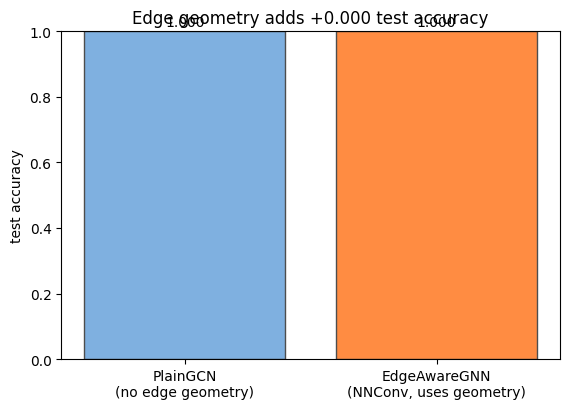

In [16]:
import matplotlib.pyplot as plt

names = ["PlainGCN\n(no edge geometry)", "EdgeAwareGNN\n(NNConv, uses geometry)"]
vals = [gcn_acc, edge_acc]
colors = ["#7fb0e0", "#ff8c42"]

fig, ax = plt.subplots(figsize=(5.8, 4.2))
bars = ax.bar(names, vals, color=colors, edgecolor="0.3")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.006, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("test accuracy")
ax.set_ylim(0, 1.0)
ax.set_title(f"Edge geometry adds {edge_acc - gcn_acc:+.3f} test accuracy")
plt.tight_layout()
plt.show()